In [1]:
import pandas as pd
from pathlib import Path

m = pd.read_parquet(Path("../data/processed/session_attack_mapping.parquet")).copy()


def as_list(value):
    if value is None:
        return []
    if isinstance(value, list):
        return value
    if hasattr(value, "tolist"):
        converted = value.tolist()
        return converted if isinstance(converted, list) else [converted]
    return [value]

In [2]:
rows = []
import matplotlib.pyplot as plt

for _, r in m.iterrows():
    techniques = as_list(r.get("mapped_techniques"))
    names = as_list(r.get("mapped_names"))
    tactics_by_tech = as_list(r.get("mapped_tactics"))
    start_ts = pd.to_datetime(r.get("start_ts"), utc=True, errors="coerce")

    n = max(len(techniques), len(names), len(tactics_by_tech), 0)
    for i in range(n):
        technique_id = techniques[i] if i < len(techniques) else None
        technique_name = names[i] if i < len(names) else None
        tactics = as_list(tactics_by_tech[i]) if i < len(tactics_by_tech) else []

        if tactics:
            for tactic in tactics:
                rows.append(
                    {
                        "source_ip": r.get("src_ip"),
                        "tactic": tactic,
                        "technique_name": technique_name,
                        "technique_id": technique_id,
                        "seen_ts": start_ts,
                    }
                )
        else:
            rows.append(
                {
                    "source_ip": r.get("src_ip"),
                    "tactic": None,
                    "technique_name": technique_name,
                    "technique_id": technique_id,
                    "seen_ts": start_ts,
                }
            )

flat = pd.DataFrame(rows)

final_output = (
    flat.groupby(
        ["source_ip", "tactic", "technique_name", "technique_id"], dropna=False
    )
    .agg(
        hits=("seen_ts", "count"),
        first_seen=("seen_ts", "min"),
        last_seen=("seen_ts", "max"),
    )
    .reset_index()
    .sort_values(["hits", "first_seen"], ascending=[False, True])
    .reset_index(drop=True)
)

final_output = final_output[
    [
        "source_ip",
        "tactic",
        "technique_name",
        "technique_id",
        "hits",
        "first_seen",
        "last_seen",
    ]
]

final_output.head(600)

,source_ip,tactic,technique_name,technique_id,hits,first_seen,last_seen
0,193.32.162.159,discovery,Security Software Discovery,T1063,1548,2023-01-18 16:15:03+00:00,2023-05-03 12:58:23+00:00
1,83.97.73.89,discovery,Security Software Discovery,T1063,649,2023-05-23 13:26:25+00:00,2023-07-05 06:08:23+00:00
2,83.97.73.87,discovery,Security Software Discovery,T1063,323,2023-07-29 07:47:40+00:00,2023-11-15 19:19:42+00:00
3,152.89.196.211,discovery,Security Software Discovery,T1063,283,2023-01-09 12:34:26+00:00,2023-04-24 01:57:50+00:00
4,94.102.61.10,discovery,Security Software Discovery,T1063,264,2023-01-09 07:28:34+00:00,2024-02-12 23:45:26+00:00
...,...,...,...,...,...,...,...
595,14.29.176.211,discovery,Security Software Discovery,T1063,7,2023-03-12 13:59:34+00:00,2023-08-17 23:54:11+00:00
596,167.94.138.127,discovery,Security Software Discovery,T1063,7,2023-03-19 19:15:59+00:00,2023-12-07 05:03:04+00:00
597,183.136.225.5,discovery,Security Software Discovery,T1063,7,2023-03-25 01:44:36+00:00,2023-07-27 03:33:06+00:00
598,64.62.197.180,discovery,Security Software Discovery,T1063,7,2023-03-25 09:44:39+00:00,2023-11-21 11:08:10+00:00


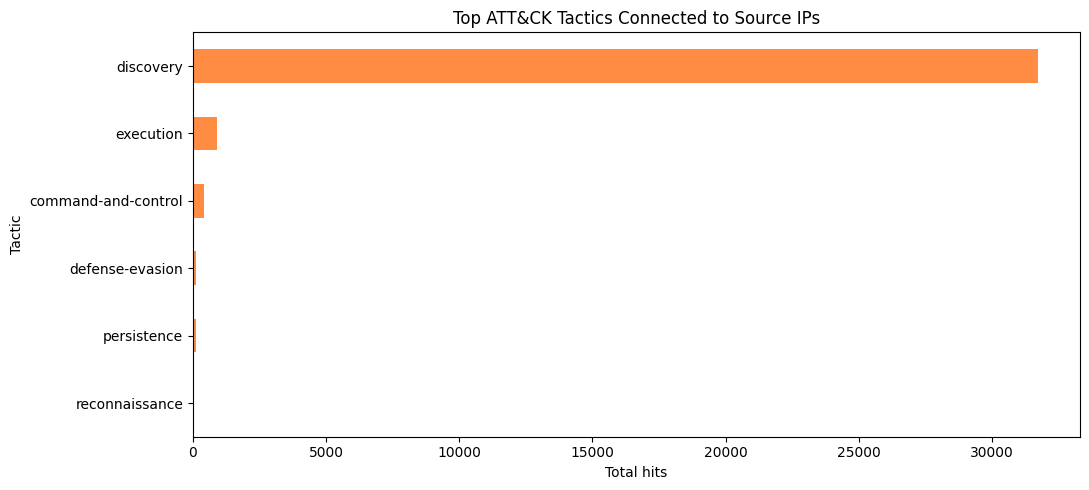

tactic
discovery              31715
execution                897
command-and-control      425
defense-evasion          132
persistence              118
reconnaissance            37
Name: hits, dtype: int64

In [3]:
# Graph 1: Top connected tactics across all source IPs (by hits)
tactic_plot = (
    final_output.dropna(subset=["tactic"])
    .groupby("tactic", dropna=False)["hits"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(11, 5))
tactic_plot.sort_values().plot(kind="barh", color="#ff8c42")
plt.title("Top ATT&CK Tactics Connected to Source IPs")
plt.xlabel("Total hits")
plt.ylabel("Tactic")
plt.tight_layout()
plt.show()

tactic_plot

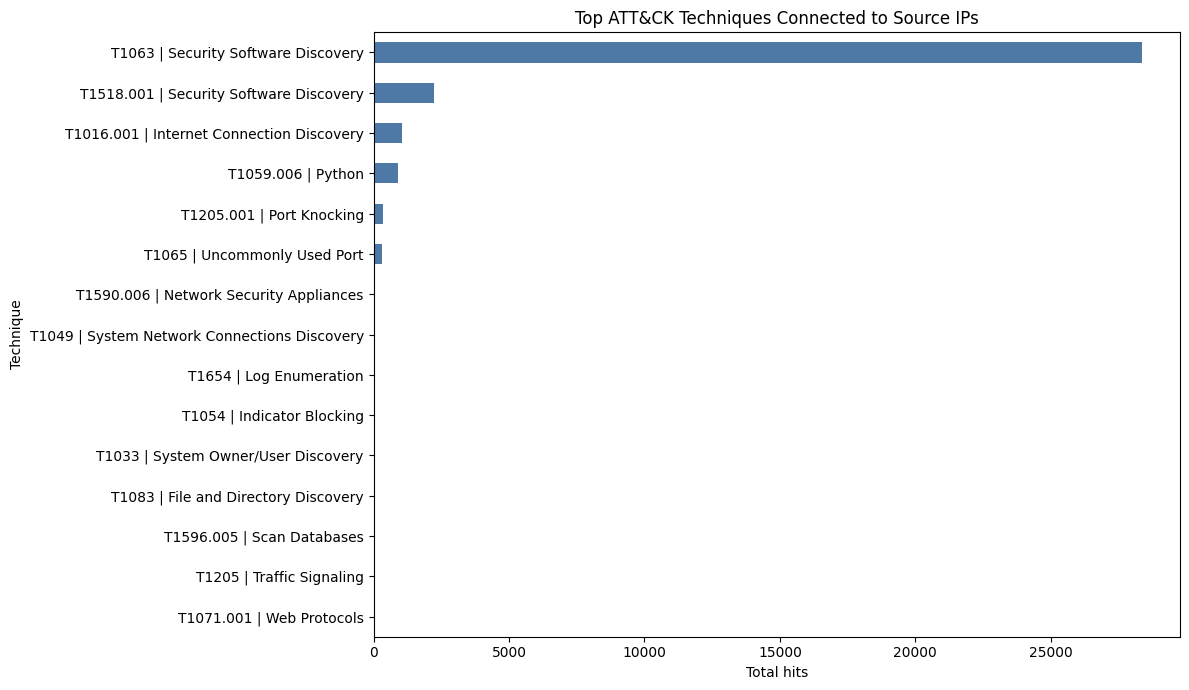

tech_label
T1063 | Security Software Discovery             28351
T1518.001 | Security Software Discovery          2243
T1016.001 | Internet Connection Discovery        1063
T1059.006 | Python                                897
T1205.001 | Port Knocking                         351
T1065 | Uncommonly Used Port                      306
T1590.006 | Network Security Appliances            31
T1049 | System Network Connections Discovery       26
T1654 | Log Enumeration                            16
T1054 | Indicator Blocking                         14
T1033 | System Owner/User Discovery                 8
T1083 | File and Directory Discovery                8
T1596.005 | Scan Databases                          6
T1205 | Traffic Signaling                           3
T1071.001 | Web Protocols                           1
Name: hits, dtype: int64

In [4]:
tech_plot = (
    final_output.assign(
        tech_label=final_output["technique_id"].fillna("NA")
        + " | "
        + final_output["technique_name"].fillna("Unknown")
    )
    .groupby("tech_label")["hits"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12, 7))
tech_plot.sort_values().plot(kind="barh", color="#4e79a7")
plt.title("Top ATT&CK Techniques Connected to Source IPs")
plt.xlabel("Total hits")
plt.ylabel("Technique")
plt.tight_layout()
plt.show()

tech_plot

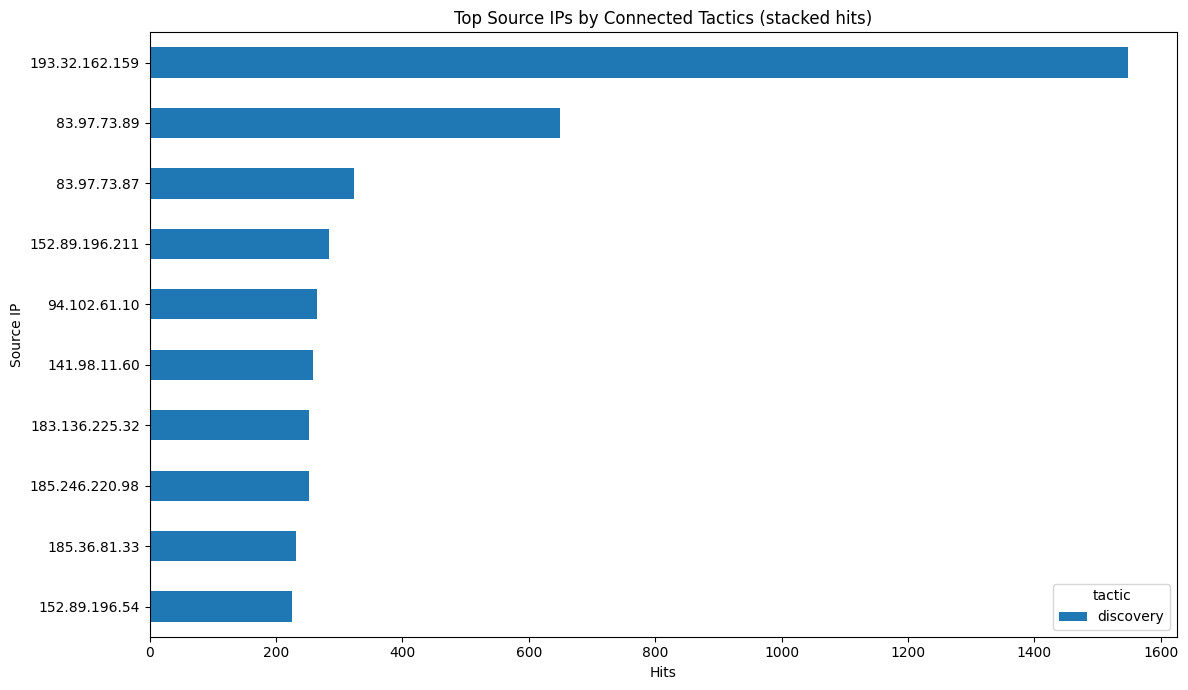

tactic,discovery
source_ip,
152.89.196.54,225
185.36.81.33,232
185.246.220.98,252
183.136.225.32,252
141.98.11.60,258
94.102.61.10,264
152.89.196.211,284
83.97.73.87,323
83.97.73.89,649


In [5]:
# Graph 3: Top source IPs and their connected tactics (stacked bar)
top_src = (
    final_output.groupby("source_ip")["hits"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)
src_tactic = (
    final_output[final_output["source_ip"].isin(top_src)]
    .copy()
    .assign(tactic=lambda d: d["tactic"].fillna("unknown"))
    .groupby(["source_ip", "tactic"])["hits"]
    .sum()
    .unstack(fill_value=0)
)

# limit legend clutter to top tactics by global weight among selected IPs
top_tactics_for_stack = (
    src_tactic.sum(axis=0).sort_values(ascending=False).head(8).index
)
src_tactic_small = src_tactic.reindex(columns=top_tactics_for_stack, fill_value=0)
other_cols = [c for c in src_tactic.columns if c not in top_tactics_for_stack]
if other_cols:
    src_tactic_small["other"] = src_tactic[other_cols].sum(axis=1)

src_tactic_small = src_tactic_small.loc[
    src_tactic_small.sum(axis=1).sort_values(ascending=True).index
]
ax = src_tactic_small.plot(kind="barh", stacked=True, figsize=(12, 7), colormap="tab20")
ax.set_title("Top Source IPs by Connected Tactics (stacked hits)")
ax.set_xlabel("Hits")
ax.set_ylabel("Source IP")
plt.tight_layout()
plt.show()

src_tactic_small

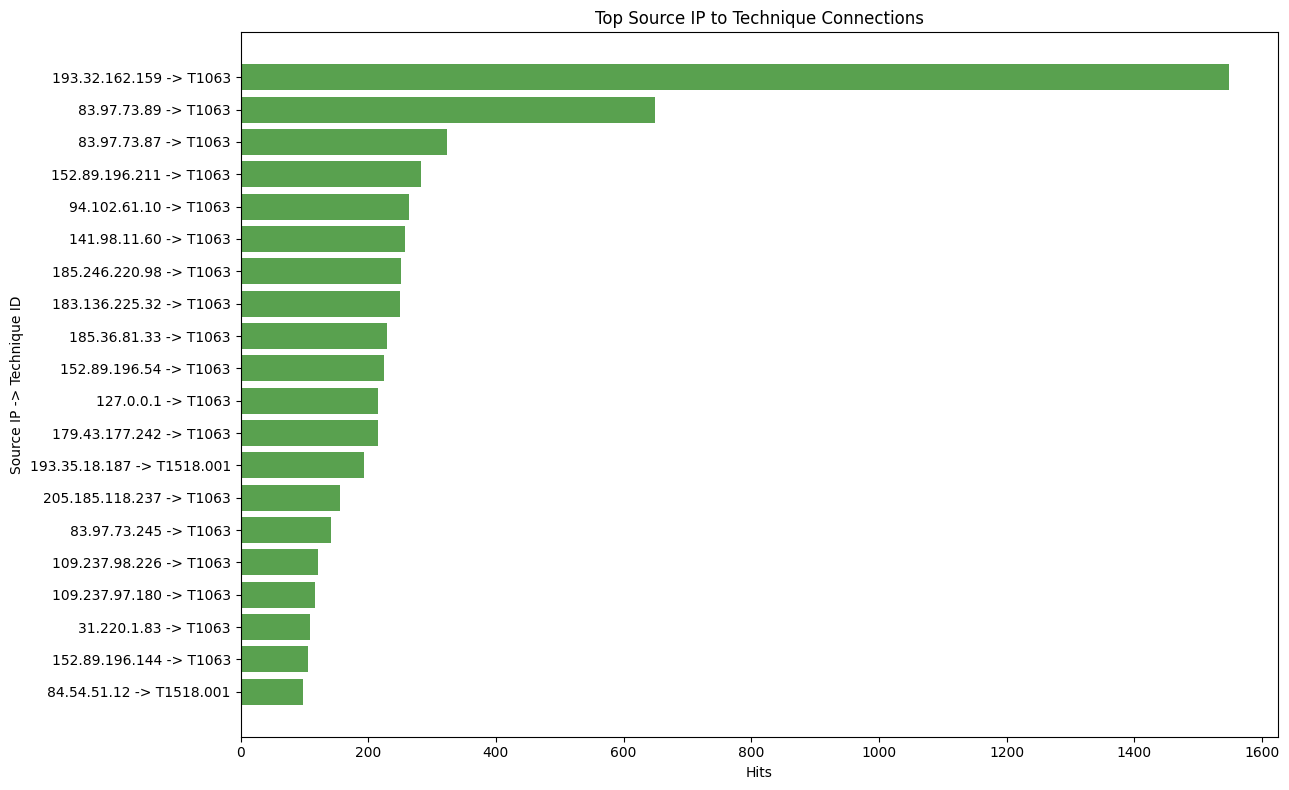

,source_ip,tactic,technique_name,technique_id,hits,first_seen,last_seen
0,193.32.162.159,discovery,Security Software Discovery,T1063,1548,2023-01-18 16:15:03+00:00,2023-05-03 12:58:23+00:00
1,83.97.73.89,discovery,Security Software Discovery,T1063,649,2023-05-23 13:26:25+00:00,2023-07-05 06:08:23+00:00
2,83.97.73.87,discovery,Security Software Discovery,T1063,323,2023-07-29 07:47:40+00:00,2023-11-15 19:19:42+00:00
3,152.89.196.211,discovery,Security Software Discovery,T1063,283,2023-01-09 12:34:26+00:00,2023-04-24 01:57:50+00:00
4,94.102.61.10,discovery,Security Software Discovery,T1063,264,2023-01-09 07:28:34+00:00,2024-02-12 23:45:26+00:00
5,141.98.11.60,discovery,Security Software Discovery,T1063,258,2023-07-27 21:22:06+00:00,2023-12-10 10:21:45+00:00
6,185.246.220.98,discovery,Security Software Discovery,T1063,252,2023-02-01 18:09:50+00:00,2023-03-10 13:03:47+00:00
7,183.136.225.32,discovery,Security Software Discovery,T1063,250,2023-01-08 08:08:43+00:00,2023-12-16 23:27:24+00:00
8,185.36.81.33,discovery,Security Software Discovery,T1063,230,2023-08-14 21:39:43+00:00,2023-11-20 13:44:47+00:00
9,152.89.196.54,discovery,Security Software Discovery,T1063,224,2023-03-09 21:36:42+00:00,2023-04-20 04:07:19+00:00


In [6]:
# Graph 4: Strongest source_ip -> technique connections
pair_plot = (
    final_output.assign(
        pair_label=final_output["source_ip"].astype(str)
        + " -> "
        + final_output["technique_id"].fillna("NA")
    )
    .sort_values("hits", ascending=False)
    .head(20)
    .copy()
)

plt.figure(figsize=(13, 8))
plt.barh(pair_plot["pair_label"][::-1], pair_plot["hits"][::-1], color="#59a14f")
plt.title("Top Source IP to Technique Connections")
plt.xlabel("Hits")
plt.ylabel("Source IP -> Technique ID")
plt.tight_layout()
plt.show()

pair_plot[
    [
        "source_ip",
        "tactic",
        "technique_name",
        "technique_id",
        "hits",
        "first_seen",
        "last_seen",
    ]
].reset_index(drop=True)